In [79]:
# Import Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report

In [80]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

Saving spotify_churn_dataset.csv to spotify_churn_dataset (3).csv


In [81]:
# Load the Sportify Churn dataset

df_sportify = pd.read_csv('spotify_churn_dataset.csv')
df_sportify.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [82]:
df_sportify.shape

(8000, 12)

**Data Splitting**

In [83]:
X = df_sportify.drop('is_churned', axis=1)
y = df_sportify['is_churned']

In [84]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42)

print('Train Size : ', X_train.shape)
print('Val Size   : ', X_val.shape)
print('Test Size  : ', X_test.shape)

Train Size :  (5780, 11)
Val Size   :  (1020, 11)
Test Size  :  (1200, 11)


**Handling Missing Values**

In [85]:
# Check Missing Values on X_train

X_train.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


In [86]:
# Check Missing Values on X_val

X_val.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


In [87]:
# Check Missing Values on X_test

X_test.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


**Feature Selection**

In [88]:
# Feature Selection

X_train.drop(['user_id'], axis=1, inplace=True)
X_val.drop(['user_id'], axis=1, inplace=True)
X_test.drop(['user_id'], axis=1, inplace=True)

X_train

,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening
7629,Other,39,IN,Student,62,28,0.56,Mobile,0,1
6200,Male,37,PK,Family,79,27,0.13,Web,0,1
1201,Male,20,AU,Premium,57,8,0.57,Desktop,0,1
3219,Other,55,FR,Student,286,39,0.20,Mobile,0,1
4320,Male,21,FR,Family,24,63,0.26,Desktop,0,1
...,...,...,...,...,...,...,...,...,...,...
1206,Other,48,UK,Family,228,20,0.32,Mobile,0,1
2106,Other,56,PK,Student,55,1,0.19,Mobile,0,1
3156,Male,35,UK,Family,180,41,0.04,Mobile,0,1
2935,Female,40,IN,Student,164,46,0.28,Web,0,1


**Pipeline**

In [89]:
# Get Numerical Columns and Categorical Columns

num_columns = X_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns : ', num_columns)
print('Categorical Columns : ', cat_columns)

Numerical Columns :  ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week', 'offline_listening']
Categorical Columns :  ['gender', 'country', 'subscription_type', 'device_type']


In [90]:
# Create A Pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy='median'),
                             StandardScaler())

cat_pipeline = make_pipeline(OneHotEncoder())

final_pipeline = ColumnTransformer([
    ('pipe_num', num_pipeline, num_columns),
    ('pipe_cat', cat_pipeline, cat_columns)
])

In [91]:
# Fit and Transform

X_train = final_pipeline.fit_transform(X_train)
X_val = final_pipeline.transform(X_val)
X_test = final_pipeline.transform(X_test)
X_train.shape

(5780, 24)

In [92]:
import joblib

joblib.dump(final_pipeline, 'final_pipeline.pkl')

['final_pipeline.pkl']

In [93]:
from google.colab import files

files.download('final_pipeline.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Model Definition**

In [94]:
# Clear session

import tensorflow as tf

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

# Check TensorFlow version
print(tf.__version__)

2.20.0


In [23]:
# Create Sequential API

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_sequential = Sequential()
model_sequential.add(Dense(16,
                           activation='relu',
                           kernel_initializer=tf.keras.initializers.HeNormal(seed),
                           input_shape=(24,)))
model_sequential.add(Dense(8,
                           activation='relu',
                           kernel_initializer=tf.keras.initializers.HeNormal(seed)))
model_sequential.add(Dense(1,
                           activation='sigmoid',
                           kernel_initializer=tf.keras.initializers.GlorotNormal(seed)))

model_sequential.compile(loss='binary_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])
model_sequential.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

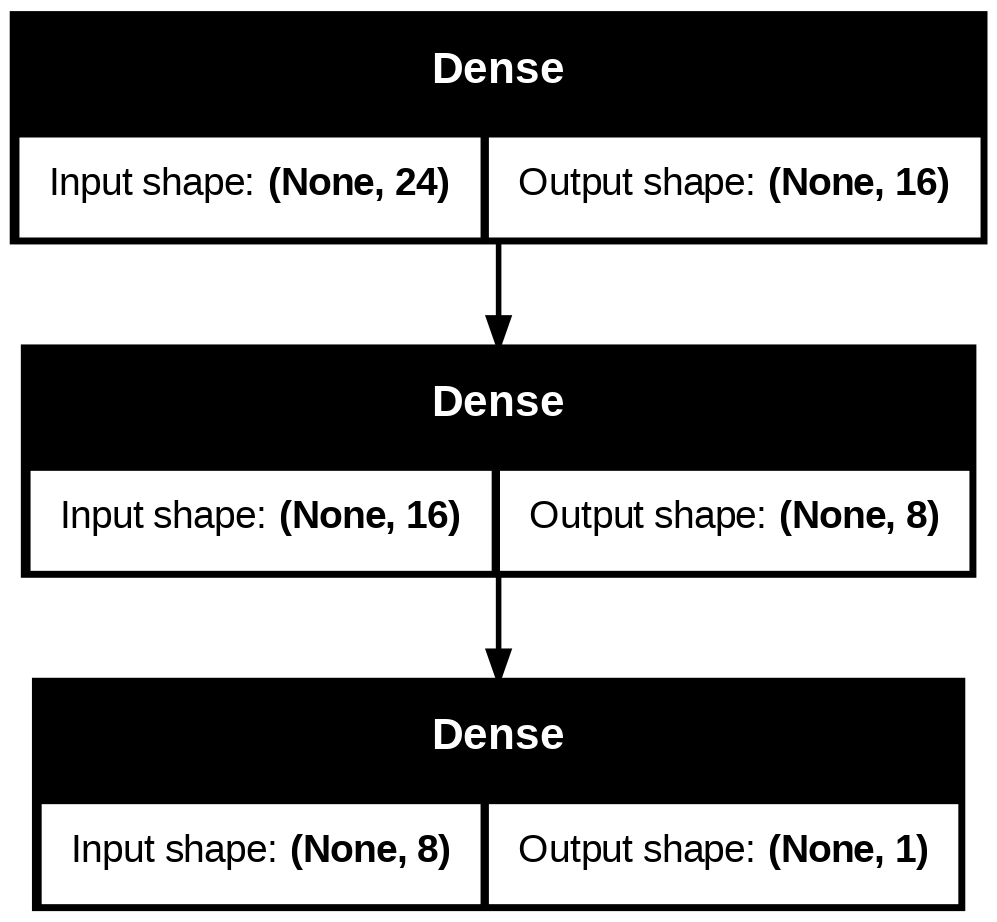

In [24]:
# Plot layers

tf.keras.utils.plot_model(model_sequential, show_shapes=True)

** Model Training**

In [25]:
print(X_train.shape)
print(X_val.shape)

(5780, 24)
(1020, 24)


In [26]:
# Train the model

%%time

history_sequential = model_sequential.fit(X_train,
                                          y_train,
                                          epochs=20,
                                          validation_data=(X_val, y_val),
                                          batch_size=10)

Epoch 1/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6869 - loss: 0.6216 - val_accuracy: 0.7441 - val_loss: 0.5759
Epoch 2/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7375 - loss: 0.5814 - val_accuracy: 0.7441 - val_loss: 0.5724
Epoch 3/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7375 - loss: 0.5773 - val_accuracy: 0.7441 - val_loss: 0.5712
Epoch 4/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5748 - val_accuracy: 0.7441 - val_loss: 0.5706
Epoch 5/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5730 - val_accuracy: 0.7441 - val_loss: 0.5699
Epoch 6/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7375 - loss: 0.5716 - val_accuracy: 0.7441 - val_loss: 0.5700
Epoch 7/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7374 - loss: 0.5702 - val_accuracy: 0.7441 - val_loss: 0.5700
Epoch 8/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7375 - loss: 0.5690 - val_accuracy: 0.

**Model Evaluation**

Text(0.5, 1.0, 'Grafik Acc vs Val-Acc')

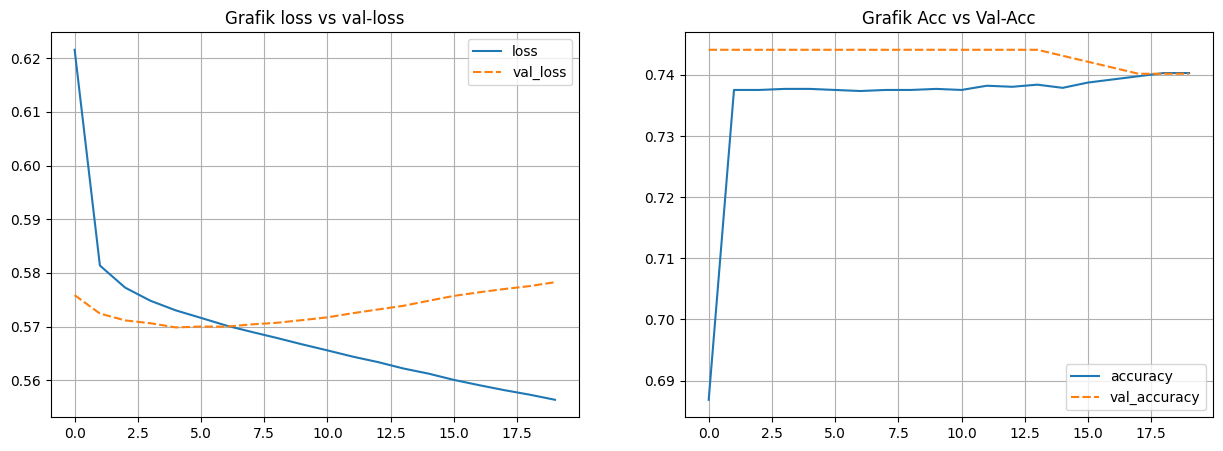

In [27]:
# Plot training result

history_sequential_df = pd.DataFrame(history_sequential.history)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_sequential_df[['loss', 'val_loss']])
plt.grid()
plt.title('Grafik loss vs val-loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_sequential_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Grafik Acc vs Val-Acc')

In [28]:
# Predict test-set

y_pred_test = model_sequential.predict(X_test)
y_pred_test

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.15842535],
       [0.23173875],
       [0.19548807],
       ...,
       [0.31411004],
       [0.16658925],
       [0.2178605 ]], dtype=float32)

In [29]:
# Model evaluation

y_pred_cls = np.where(y_pred_test >= 0.5, 1, 0)
print(classification_report(y_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.75      0.99      0.86       906
           1       0.22      0.01      0.01       294

    accuracy                           0.75      1200
   macro avg       0.49      0.50      0.44      1200
weighted avg       0.62      0.75      0.65      1200



***Functional API***

**Model Definition**

In [30]:
# Clear session

import tensorflow as tf
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [31]:
# Create functional model

from tensorflow.keras.layers import Input, concatenate
from tensorflow.keras import Model

input_layer = Input(shape=(24,))
hidden_layer_1 = Dense(16, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed)) (input_layer)
hidden_layer_2 = Dense(8, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed)) (hidden_layer_1)
concat_layer = concatenate([hidden_layer_2, input_layer])
output_layer = Dense(1, activation='sigmoid', kernel_initializer=tf.keras.initializers.GlorotNormal(seed)) (concat_layer)

model_functional = Model(inputs = input_layer, outputs = output_layer)

# Compile
model_functional.compile(loss='binary_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])
model_functional.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        400 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 569 (2.22 KB)

 Trainable params: 569 (2.22 KB)

 Non-trainable params: 0 (0.00 B)

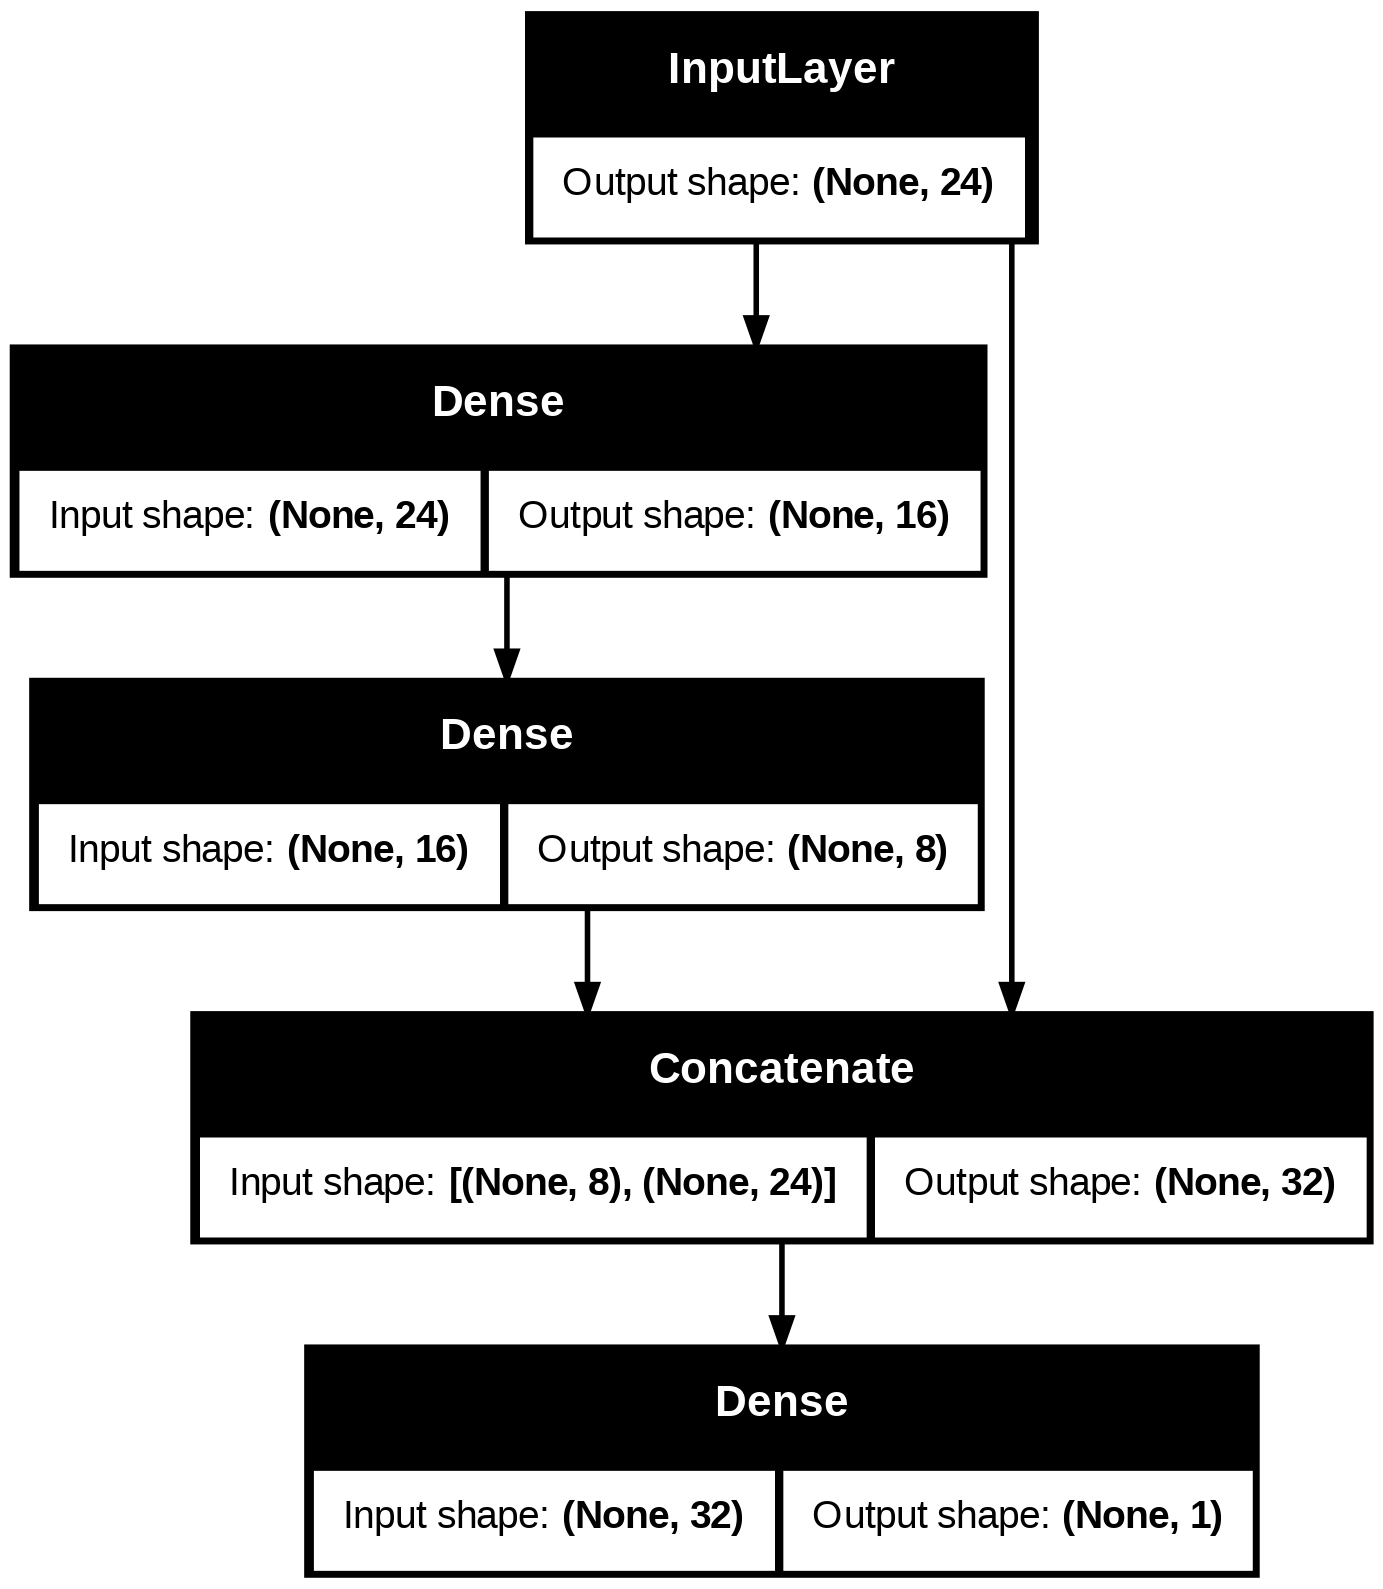

In [32]:
# Plot layers

tf.keras.utils.plot_model(model_functional, show_shapes=True)

**Model Training**

In [33]:
# Train the model

%%time
history_functional = model_functional.fit(X_train,
                                          y_train,
                                          epochs=20,
                                          validation_data=(X_val, y_val),
                                          batch_size=10)

Epoch 1/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6562 - loss: 0.6461 - val_accuracy: 0.7441 - val_loss: 0.5833
Epoch 2/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5808 - val_accuracy: 0.7441 - val_loss: 0.5747
Epoch 3/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5757 - val_accuracy: 0.7441 - val_loss: 0.5725
Epoch 4/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5735 - val_accuracy: 0.7441 - val_loss: 0.5716
Epoch 5/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5720 - val_accuracy: 0.7441 - val_loss: 0.5709
Epoch 6/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5709 - val_accuracy: 0.7441 - val_loss: 0.5707
Epoch 7/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7377 - loss: 0.5700 - val_accuracy: 0.7441 - val_loss: 0.5706
Epoch 8/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7379 - loss: 0.5691 - val_accuracy: 0.

**Model Evaluation**

Text(0.5, 1.0, 'Grafik Acc vs Val-Acc')

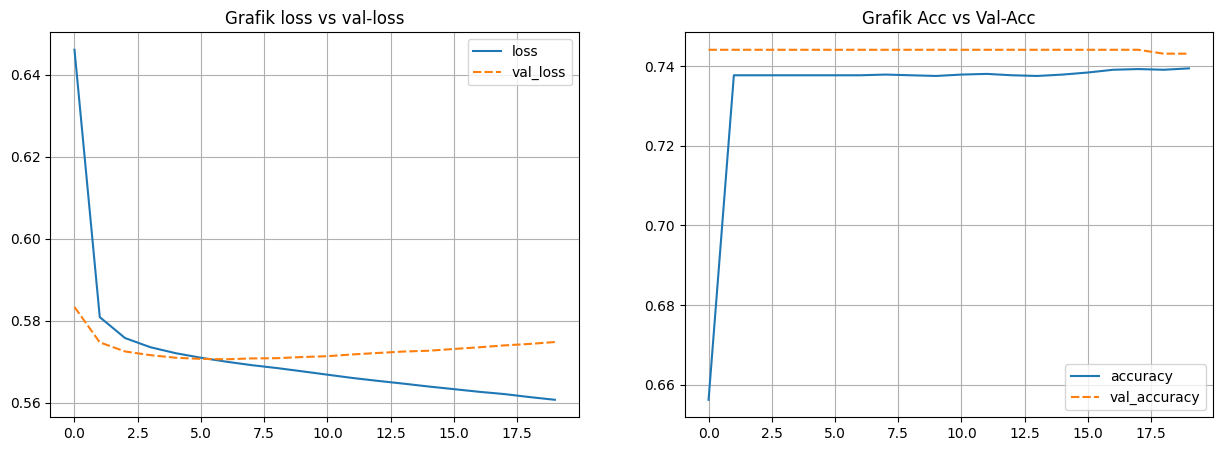

In [34]:
# Plot training result

history_functional_df = pd.DataFrame(history_functional.history)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_functional_df[['loss', 'val_loss']])
plt.grid()
plt.title('Grafik loss vs val-loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_functional_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Grafik Acc vs Val-Acc')

In [35]:
# Model Evaluation

y_pred_func = model_functional.predict(X_test)
y_pred_cls = np.where(y_pred_func >= 0.5, 1, 0)

print(classification_report(y_test, y_pred_cls))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       906
           1       0.25      0.00      0.01       294

    accuracy                           0.75      1200
   macro avg       0.50      0.50      0.43      1200
weighted avg       0.63      0.75      0.65      1200



** Model Saving**

In [36]:
# Save Pipeline

import pickle

with open('titanic_pipeline.pkl', 'wb') as file_1:
  pickle.dump(final_pipeline, file_1)

In [37]:
# Model summary

model_sequential.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,637 (6.40 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,092 (4.27 KB)

In [97]:
import pandas as pd

history_df = pd.DataFrame(history_sequential.history)

history_df.to_csv('history_ann.csv', index=False)

In [98]:
from google.colab import files

files.download('history_ann.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# Save ANN model

model_sequential.save('titanic_model.keras', include_optimizer=True)

In [40]:
model_sequential.save('spotify_churn_model.keras')

In [41]:
from google.colab import files

files.download('spotify_churn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
df_sportify['gender'].unique()

array(['Female', 'Other', 'Male'], dtype=object)

In [63]:
df_sportify['subscription_type'].unique()

array(['Free', 'Family', 'Premium', 'Student'], dtype=object)

In [62]:
df_sportify['country'].unique()

array(['CA', 'DE', 'AU', 'US', 'UK', 'IN', 'FR', 'PK'], dtype=object)

In [64]:
df_sportify['device_type'].unique()

array(['Desktop', 'Web', 'Mobile'], dtype=object)

In [96]:
history_sequential.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])